**Pedro's Analytical Rio Coca Evolution Model (PARCEM)**

This model is based on theory presented in 'RCO ESTUDIO FLUVIOMORFOLÓGICO DEL RÍO COCA – ACTUALIZACIÓN 10' by Pedro Crespo, Nov. 2025.

***Current Notes:***

[1] There is a calibration mode used to test a matrix of parameter space, the output is not formatted well.

[2] The code expects .csv files for the channel profile, discharge time series, and total sediment flux calibration data.

[3] Takes like 2 minutes to run one 2000 day simulation.

Latest version is 3FEB2026

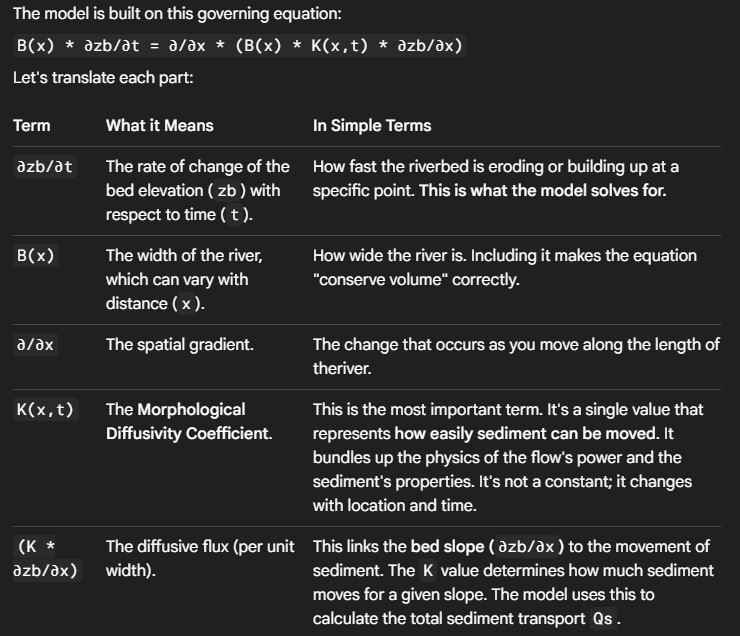

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import os
import itertools
from datetime import datetime, timedelta
import scipy.signal as signal

# ==========================================
# 1. CONFIGURATION & CONTROL BOARD
# ==========================================
# GEOMORPHIC THEORY CONTEXT:
# This model implements a 1D Morphodynamic Simulation of a river profile (e.g., Rio Coca).
# It operates under the "Transport-Limited" assumption, where the sediment flux is determined
# by the local hydraulic capacity to move sediment, rather than the availability of sediment
# (Detachment-Limited). This results in a diffusive evolution of the landscape.
#
# Key Processes:
# 1. Fluvial Vertical Incision/Deposition: Governed by the Exner Equation.
# 2. Lateral Channel Dynamics: Bank erosion coupled to vertical incision.

CALIBRATION_MODE = False  # Set to True to run parameter sweep
ANIMATION_MODE = True    # Set to True to generate an animation of the profile evolution
TRANSPORT_MODE = 'Transport_Limited' # Options: 'Transport_Limited', 'Blended'

# Paths
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/PARCEM - Model'
BATHY_PATH = os.path.join(BASE_DIR, 'Initial_Bathy.csv')
DISCHARGE_PATH = os.path.join(BASE_DIR, 'Discharge_Timeseries.csv')
CAL_PATH = os.path.join(BASE_DIR, 'Calibration.csv')
OUTPUT_BASE_DIR = os.path.join(BASE_DIR, 'Calibration_Results')

# Constants & Fixed Parameters
WATERFALL_POS = 19000
HILLSLOPE_SLOPE = 0.40  # Geometry of the valley walls
RAMP_DISTANCE = 3000.0
INITIAL_BANK_HEIGHT = 3.0
USE_BANK_EROSION = True # Enables the coupling between vertical incision and lateral widening
L_ADAPT = 1000.0 # Adaptation length for Blended mode (meters)

# Parameter Ranges (Only used if CALIBRATION_MODE is True)
# Geomorphic parameters defining transport efficiency and channel geometry response.
CALIBRATION_PARAMS = {
    'a': [0.002, 0.0025, 0.003], # Transport coefficient pre-factor
    'n': [2.0, 2.5, 3.0],        # Non-linearity of transport with discharge (e.g., stream power exponent)
    'b': [3],                    # Exponent related to shear stress/velocity relation
    'bank_widening_factor': [4.0], # Sensitivity of bank retreat to incision depth
    'slope_factor': [0.8, 1.0, 1.2],
    'width_factor': [1.0]
}

# Default Parameters (Used if CALIBRATION_MODE is False)
DEFAULT_PARAMS = {
    'a': 0.002,
    'n': 1.5,
    'b': 3,
    'bank_widening_factor': 4.0,
    'US_slope_factor': 1.0,
    'DS_width_factor': 1.0
}

# ==========================================
# 2. DATA LOADING (Global Scope)
# ==========================================
def load_data():
    # Load Initial Bathymetry (Longitudinal Profile z vs x)
    if os.path.exists(BATHY_PATH):
        df_bathy = pd.read_csv(BATHY_PATH)
        x = df_bathy.iloc[:, 0].values
        zb0 = df_bathy.iloc[:, 1].values
        nx = len(x)
        L = x[-1] - x[0]
        dx = L / (nx - 1)
        print(f"Loaded bathymetry: {nx} points over {L/1000:.2f} km.")
    else:
        print(f"Warning: {BATHY_PATH} not found. Using synthetic profile.")
        nx = 200
        L = 100000
        dx = L / (nx - 1)
        x = np.linspace(0, L, nx)
        base_elevation = 250.0
        waterfall_height = 100.0
        slope_initial = -0.0005
        zb0 = np.full(nx, base_elevation)
        zb0[x > WATERFALL_POS] = base_elevation - waterfall_height + slope_initial * (x[x > WATERFALL_POS] - WATERFALL_POS)
        zb0 += slope_initial * x

    # Load Discharge Time Series (Hydrologic Driver)
    if os.path.exists(DISCHARGE_PATH):
        df_q = pd.read_csv(DISCHARGE_PATH)
        date_col_q = df_q.columns[0]
        df_q[date_col_q] = pd.to_datetime(df_q[date_col_q], format='mixed')
        Q = df_q.iloc[:, 1].values
        nt = len(Q)
        start_date = df_q[date_col_q].iloc[0]
        duration = df_q[date_col_q].iloc[-1] - start_date
        total_time_days = duration.total_seconds() / (24 * 3600.0)
        dt_days = total_time_days / (nt - 1)
        dt_secs = dt_days * 24 * 3600
        print(f"Loaded discharge: {nt} steps over {total_time_days:.2f} days.")
    else:
        print(f"Warning: {DISCHARGE_PATH} not found. Using synthetic discharge.")
        nt = 2000
        total_time_days = 2000
        dt_days = total_time_days / nt
        dt_secs = dt_days * 24 * 3600
        Q = np.full(nt, 500.0)
        Q[500:550] = 1500
        Q[1200:1280] = 2000
        start_date = pd.Timestamp.now()

    # Load Calibration Data (Observed Sediment Volumes)
    df_cal = None
    cal_time_days = None
    cal_vol = None
    if os.path.exists(CAL_PATH):
        df_cal = pd.read_csv(CAL_PATH)
        date_col_cal = df_cal.columns[0]
        df_cal[date_col_cal] = pd.to_datetime(df_cal[date_col_cal], format='mixed')
        cal_vol = df_cal.iloc[:, 1].values
        cal_time_days = (df_cal[date_col_cal] - start_date).dt.total_seconds() / (24 * 3600.0)
        print(f"Loaded calibration data: {len(df_cal)} records.")

    return x, zb0, nx, dx, Q, nt, total_time_days, dt_days, dt_secs, df_cal, cal_time_days, cal_vol, start_date

# Load data once
X_GLOBAL, ZB0_GLOBAL, NX_GLOBAL, DX_GLOBAL, Q_GLOBAL, NT_GLOBAL, TOTAL_TIME_DAYS, DT_DAYS, DT_SECS, DF_CAL, CAL_TIME_DAYS, CAL_VOL, START_DATE = load_data()


# ==========================================
# 3. SIMULATION ENGINE
# ==========================================
def run_simulation(params, run_id="Single_Run", output_dir=None):
    """
    Runs the morphological model for a given set of parameters.
    """
    # Unpack parameters
    a = params['a']
    n = params['n']
    b = params['b']
    bank_widening_factor = params['bank_widening_factor']
    if CALIBRATION_MODE == False:
      US_slope_factor = params.get('slope_factor', 1.0)
      DS_slope_factor = params.get('slope_factor', 1.0)
    else:
      US_slope_factor = params.get('US_slope_factor', 1.0)
      DS_slope_factor = params.get('DS_slope_factor', 1.0)
    width_factor = params.get('width_factor', 1.0)

    print(f"Running Simulation {run_id} [{TRANSPORT_MODE}]: a={a}, n={n}, b={b}, bank_factor={bank_widening_factor}")

    # --- Setup IC/BC ---
    # Define Equilibrium Slope (Graded Stream Concept)
    # The river tends toward this slope where sediment supply equals transport capacity.
    ib = np.zeros(NX_GLOBAL)
    ib[X_GLOBAL < 42500] = 0.0091 * US_slope_factor
    ib[(X_GLOBAL >= 42500) & (X_GLOBAL < 47000)] = 0.012 * US_slope_factor
    ib[X_GLOBAL >= 47000] = 0.0065 * DS_slope_factor

    # Construct Equilibrium Profile
    zb_eq = np.zeros(NX_GLOBAL)
    zb_eq[-1] = ZB0_GLOBAL[-1]
    for i in range(NX_GLOBAL - 2, -1, -1):
        zb_eq[i] = zb_eq[i+1] + ib[i] * DX_GLOBAL

    # Channel Width (Hydraulic Geometry)
    # Width is a critical parameter in unit stream power calculations (Q/B).
    B = np.full(NX_GLOBAL, 100.0 * width_factor)
    B[(X_GLOBAL > 44000) & (X_GLOBAL < 47000)] = 50 * width_factor # Narrow reach
    B[X_GLOBAL > 65000] = 200 * width_factor # Wide reach
    B0 = B.copy()
    B_dynamic = B.copy()
    B_history = np.zeros((NT_GLOBAL, NX_GLOBAL))
    B_history[0, :] = B_dynamic

    # Bank Widening Array
    # Spatially variable sensitivity of banks to incision (e.g., varying lithology).
    bank_widening_array = np.full(NX_GLOBAL, bank_widening_factor)
    mask_ramp = (X_GLOBAL >= WATERFALL_POS - RAMP_DISTANCE) & (X_GLOBAL <= WATERFALL_POS + RAMP_DISTANCE)
    reduced_factor = bank_widening_factor / 4.0
    dist_from_wf = np.abs(X_GLOBAL[mask_ramp] - WATERFALL_POS)
    bank_widening_array[mask_ramp] = reduced_factor + (bank_widening_factor - reduced_factor) * (dist_from_wf / RAMP_DISTANCE)

    # --- Simulation Variables ---
    zb = np.zeros((NT_GLOBAL, NX_GLOBAL))
    zb[0, :] = ZB0_GLOBAL
    cumulative_bank_sediment = np.zeros(NT_GLOBAL)

    # Flux Tracking Locations
    # Updated based on user request for Time Series plot
    target_xs = {
        'Flux @ Waterfall': WATERFALL_POS,
        'Flux @ +1 km': WATERFALL_POS + 1000,
        'Flux @ +5 km': WATERFALL_POS + 5000,
        'Flux @ +10 km': WATERFALL_POS + 10000,
        'Flux @ 52 km': 52000,
        'Flux @ 62 km': 62000,
        'Flux @ Outlet': X_GLOBAL[-1] # Added Flux leaving domain
    }
    target_indices = {k: np.argmin(np.abs(X_GLOBAL - val)) for k, val in target_xs.items()}
    flux_history = {k: np.zeros(NT_GLOBAL) for k in target_xs.keys()}

    # Binned Tracking (10km bins relative to WF)
    # Create bins aligned with WF position (19000). E.g., ... 9000, 19000, 29000 ...
    # Let's generate edges covering the whole domain.
    # Bins will be defined by lower edges.
    bin_size = 10000.0
    # Start from WF - int(WF/bin_size)*bin_size to cover 0
    offset = WATERFALL_POS % bin_size
    # Ensure we cover negative if needed (though domain starts at 0)
    bin_edges = np.arange(offset - bin_size, X_GLOBAL[-1] + bin_size, bin_size)
    # We align strictly to have a break at WF (19000).
    # If WF=19000, bin edges could be: -1000, 9000, 19000, 29000, 39000...
    bin_edges = np.arange(WATERFALL_POS - (np.ceil(WATERFALL_POS/bin_size)*bin_size),
                          X_GLOBAL[-1] + bin_size, bin_size)

    # Identify which bin each spatial cell belongs to
    bin_mapping = np.digitize(X_GLOBAL, bin_edges) - 1
    n_bins = len(bin_edges) - 1
    bin_eroded_vol_cum = np.zeros(n_bins)
    bin_aggraded_vol_cum = np.zeros(n_bins)

    # Bed Change Tracking for plots (Snapshots)
    bed_change_profiles = {}
    # Snapshots at 1/4, 1/2, 3/4, 4/4
    snapshot_times = [int(NT_GLOBAL * 0.25), int(NT_GLOBAL * 0.50), int(NT_GLOBAL * 0.75), NT_GLOBAL - 1]

    # Pre-calc constants
    # K_prefactor: Aggregated transport coefficient.
    # In physical terms, this lumps bed roughness, sediment grain size, and channel constants.
    # It relates flow properties to sediment transport capacity.
    K_prefactor = (b * a) / (3 * np.maximum(ib, 1e-6))

    if USE_BANK_EROSION:
        # Terrain geometry for bank erosion calculation.
        # Assumes a V-shaped or trapezoidal valley cross-section.
        terrain_const = ZB0_GLOBAL + INITIAL_BANK_HEIGHT - (B0 * HILLSLOPE_SLOPE / 2.0)
        terrain_slope_factor = HILLSLOPE_SLOPE / 2.0

    # Animation Setup
    anim_frames = []
    anim_dates = []
    anim_fps = 30
    anim_duration = 20 # Seconds
    total_anim_frames = anim_fps * anim_duration
    anim_stride = max(1, int(NT_GLOBAL / total_anim_frames))

    # Helper Gradient Function (Central Difference)
    def fast_gradient(arr, dx):
        grad = np.empty_like(arr)
        grad[0] = (arr[1] - arr[0]) / dx
        grad[-1] = (arr[-1] - arr[-2]) / dx
        grad[1:-1] = (arr[2:] - arr[:-2]) / (2 * dx)
        return grad

    # --- Time Loop (Geomorphic Evolution) ---
    for t in range(NT_GLOBAL - 1):
        Qt = Q_GLOBAL[t]

        # 1. Calculate Transport Capacity (K_local)
        # Based on unit discharge (q = Q/B). A power law relation is used:
        # K ~ (Q/B)^n. This represents the capacity of the flow to move sediment.
        K_local = K_prefactor * (Qt / B_dynamic)**n

        # Adaptive Time Stepping (CFL Condition)
        # Ensures numerical stability for the diffusive process.
        K_max = np.max(K_local)
        dt_crit = 0.4 * (DX_GLOBAL**2) / K_max if K_max > 1e-12 else DT_SECS
        dt_sub = min(DT_SECS, max(0.1, dt_crit))

        time_remaining = DT_SECS
        zb_current = zb[t, :].copy()
        step_bank_sed_vol = 0.0

        # Track accumulated change in this timestep for binning
        dz_step = np.zeros(NX_GLOBAL)

        # Temp flux storage for this step (average rate)
        qs_step_sum = np.zeros(len(target_xs))
        qs_step_count = 0
        target_idx_list = list(target_indices.values())

        while time_remaining > 0:
            current_dt = min(time_remaining, dt_sub)

            # 2. Calculate Sediment Flux (Qs)
            # Transport-Limited Assumption: Qs is proportional to Slope (S = -dz/dx).
            # This implies the system is diffusive: dz/dt ~ d2z/dx2.
            # If slope increases, flux increases.
            dzbdx = fast_gradient(zb_current, DX_GLOBAL)
            Qc = -B_dynamic * K_local * dzbdx # Transport Capacity (Potential Flux)

            if TRANSPORT_MODE == 'Blended':
                 # Linear Adaptation: dQs/dx = (Qc - Qs) / L
                 # Recurrence: Qs[i] = alpha*Qs[i-1] + (1-alpha)*Qc[i]
                 alpha = np.exp(-DX_GLOBAL / L_ADAPT)
                 b_filt = [1.0 - alpha]
                 a_filt = [1.0, -alpha]
                 # IC: Assume equilibrium at inflow
                 zi = signal.lfilter_zi(b_filt, a_filt) * Qc[0]
                 Qs, _ = signal.lfilter(b_filt, a_filt, Qc, zi=zi)

                 # Calculate divergence based on disequilibrium
                 dQs_dx = (Qc - Qs) / L_ADAPT
            else:
                 # Pure Transport Limited
                 Qs = Qc
                 dQs_dx = fast_gradient(Qs, DX_GLOBAL)

            # 3. Exner Equation (Conservation of Mass)
            # Change in elevation (dz/dt) = - Divergence of Sediment Flux (dQs/dx) / Width
            # If more sediment leaves a cell than enters (dQs/dx > 0), the bed erodes (dz < 0).
            # Note: dQs_dx calculated above based on mode
            dz_dt_flow = - (1.0 / B_dynamic) * dQs_dx
            dz_flow = dz_dt_flow * current_dt

            # Save flux rates
            qs_step_sum += Qs[target_idx_list]
            qs_step_count += 1

            # 4. Bank Erosion Mechanism (Coupling Vertical to Lateral)
            if USE_BANK_EROSION:
                # Incision (negative dz) destabilizes banks.
                incision = np.maximum(0.0, -dz_flow)

                # Channel widens proportional to incision.
                dB = incision * bank_widening_array

                # Calculate volume of material derived from bank collapse.
                # Geometric argument based on bank height and widening distance.
                z_terrain = terrain_const + (B_dynamic * terrain_slope_factor)
                h_bank = np.maximum(0.0, z_terrain - zb_current)
                area_bank_sed = h_bank * dB
                step_bank_sed_vol += np.sum(area_bank_sed) * DX_GLOBAL

                # Distribute bank sediment across the bed.
                # This acts as a source term in the Exner equation, buffering incision.
                dz_bank = area_bank_sed / (B_dynamic + dB)

                B_dynamic += dB
                net_change = dz_flow + dz_bank # Net Elevation Change
                zb_current += net_change
                dz_step += net_change
            else:
                zb_current += dz_flow
                dz_step += dz_flow

            # Boundary Conditions
            zb_current[0] = ZB0_GLOBAL[0] # Fixed upstream elevation (or knickpoint)
            zb_current[-1] = zb_current[-2] + (zb_current[-2] - zb_current[-3]) # Constant slope downstream

            time_remaining -= current_dt

        zb[t+1, :] = zb_current
        B_history[t+1, :] = B_dynamic.copy()
        cumulative_bank_sediment[t+1] = cumulative_bank_sediment[t] + step_bank_sed_vol

        # Capture frame for animation
        if ANIMATION_MODE and (t % anim_stride == 0):
            anim_frames.append(zb_current.copy())
            anim_dates.append(START_DATE + timedelta(days=t * DT_DAYS))

        # Store avg flux for the timestep
        if qs_step_count > 0:
            avg_flux = qs_step_sum / qs_step_count
            for i, name in enumerate(target_xs.keys()):
                flux_history[name][t] = avg_flux[i]
        else:
            for name in target_xs.keys():
                flux_history[name][t] = 0.0

        # Bin Statistics (Net Erosion/Aggradation per bin this step)
        # Volume change at each cell = dz_step * Width * dx
        dv_step = dz_step * B_dynamic * DX_GLOBAL

        # For each bin, sum positive dV (agg) and negative dV (ero)
        # Vectorized sum by bin index
        # Using np.bincount for speed (works for summing weights)
        # Separate positive and negative changes
        agg_step = np.where(dv_step > 0, dv_step, 0)
        ero_step = np.where(dv_step < 0, dv_step, 0)

        # Ensure bin_mapping is within range (handles edges if any)
        # Note: bin_mapping size is NX_GLOBAL
        bin_aggraded_vol_cum += np.bincount(bin_mapping, weights=agg_step, minlength=n_bins)
        bin_eroded_vol_cum += np.bincount(bin_mapping, weights=ero_step, minlength=n_bins)

        # Store Snapshots
        if (t+1) in snapshot_times:
            bed_change_profiles[t+1] = zb[t+1, :] - ZB0_GLOBAL

    # --- Metrics & Analysis ---
    # Using waterfall location flux as reference for calibration
    cum_flux_wf = np.cumsum(flux_history['Flux @ Waterfall']) * DT_SECS
    total_flux_wf = cum_flux_wf[-1]

    # Flux at Outlet (leaving domain)
    cum_flux_outlet = np.cumsum(flux_history['Flux @ Outlet']) * DT_SECS
    total_flux_outlet = cum_flux_outlet[-1]

    # AOI Storage
    flux_52 = np.sum(flux_history['Flux @ 52 km']) * DT_SECS
    flux_62 = np.sum(flux_history['Flux @ 62 km']) * DT_SECS
    aoi_storage_pct = ((flux_52 - flux_62) / flux_52) * 100 if flux_52 > 0 else 0.0

    # Total Sediment Storage %
    # (Eroded from WF - Leaving Domain) / Eroded from WF * 100
    total_storage_pct = 0.0
    if total_flux_wf > 0:
        total_storage_pct = ((total_flux_wf - total_flux_outlet) / total_flux_wf) * 100.0

    # RMSE
    rmse = np.nan
    if DF_CAL is not None:
        time_days_arr = np.linspace(0, TOTAL_TIME_DAYS, NT_GLOBAL)
        cal_indices = [np.argmin(np.abs(time_days_arr - t_cal)) for t_cal in CAL_TIME_DAYS]
        sim_vol_at_cal = cum_flux_wf[cal_indices]
        rmse = np.sqrt(np.mean((CAL_VOL - sim_vol_at_cal)**2))

    # Prepare Summary Data
    summary_data = {
        'Run_ID': run_id,
        'Transport_Mode': TRANSPORT_MODE,
        'a': a, 'n': n, 'b': b,
        'bank_widening_factor': bank_widening_factor,
        'US_slope_factor': US_slope_factor,
        'DS_slope_factor': DS_slope_factor,
        'width_factor': width_factor,
        'RMSE': rmse,
        'Total_Flux_WF': total_flux_wf,
        'Flux_Leaving_Domain': total_flux_outlet,
        'Total_Storage_Pct': total_storage_pct,
        'AOI_Storage_Pct': aoi_storage_pct
    }

    # --- Animation Generation ---
    if ANIMATION_MODE:
        print("Generating Animation... (This may take a minute)")
        fig, ax = plt.subplots(figsize=(12, 6))

        # Initial profile
        ax.plot(X_GLOBAL/1000, ZB0_GLOBAL, 'k--', label='Initial Bed')

        # Evolving profile (placeholder)
        line, = ax.plot([], [], 'b-', linewidth=2, label='Current Profile')

        # Text for date
        date_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12)

        ax.set_xlabel('Longitudinal distance (km)')
        ax.set_ylabel('Elevation (m)')
        ax.set_title(f'River Profile Evolution - Run {run_id}')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Set limits based on overall range
        ax.set_xlim(X_GLOBAL[0]/1000, X_GLOBAL[-1]/1000)
        min_z = np.min(zb)
        max_z = np.max(zb)
        range_z = max_z - min_z
        ax.set_ylim(min_z - 0.1*range_z, max_z + 0.1*range_z)

        def init():
            line.set_data([], [])
            date_text.set_text('')
            return line, date_text

        def animate(i):
            if i < len(anim_frames):
                z_data = anim_frames[i]
                d_val = anim_dates[i]
                line.set_data(X_GLOBAL/1000, z_data)
                date_text.set_text(f'Date: {d_val.strftime("%Y-%m-%d")}')
            return line, date_text

        anim = animation.FuncAnimation(fig, animate, init_func=init,
                                       frames=len(anim_frames), interval=1000/anim_fps, blit=True)

        save_path = os.path.join(os.getcwd(), f'River_Evolution_{run_id}.mp4')
        try:
            anim.save(save_path, writer='ffmpeg', fps=anim_fps)
            print(f"Animation saved to {save_path}")
        except:
             print("FFmpeg not found or error, saving as GIF.")
             save_path = save_path.replace('.mp4', '.gif')
             anim.save(save_path, writer='pillow', fps=anim_fps)
             print(f"Animation saved to {save_path}")

        plt.close(fig)
        return summary_data

    # --- Static Plotting (Original) ---
    if not ANIMATION_MODE:
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 20))
        plt.subplots_adjust(hspace=0.4, bottom=0.25) # Extra bottom space for table

        # --- Plot 1: Longitudinal Profile ---
        ax1.plot(X_GLOBAL/1000, ZB0_GLOBAL, 'k--', label='Initial Bed')
        ax1.plot(X_GLOBAL/1000, zb[-1, :], 'b-', linewidth=2, label='Final Bed')
        ax1.plot(X_GLOBAL/1000, zb_eq, 'g:', alpha=0.5, label='Equilibrium Profile')
        ax1.set_xlabel('Longitudinal distance (km)')
        ax1.set_ylabel('Elevation (m)')
        ax1.set_title(f'Longitudinal Profile - Run {run_id}')
        ax1.grid(True, alpha=0.3)

        # Second Y-axis for Bed Change
        ax1_right = ax1.twinx()
        ax1_right.set_ylabel('Bed Change (m)', color='gray')

        # Plot bed change lines in grayscale (getting darker)
        for i, t_snap in enumerate(snapshot_times):
            change = bed_change_profiles[t_snap]
            gray_val = 0.8 - (0.8 * (i / 3.0)) # 0.8 down to 0.0 (black)
            label_t = f'Bed Change {int((i+1)*25)}% Sim. Time'
            ax1_right.plot(X_GLOBAL/1000, change, color=str(gray_val), linestyle='-', alpha=0.7, label=label_t)

        ax1_right.tick_params(axis='y', labelcolor='gray')

        # Combine legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax1_right.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

        # --- Plot 2: Time Series ---
        time_arr = np.linspace(0, TOTAL_TIME_DAYS, NT_GLOBAL)
        ax2.set_xlabel('Time (days)')
        ax2.set_ylabel('Cumulative Sediment Flux (m3)')
        ax2.set_title('Time Series')

        # Plot fluxes
        cum_flux_52 = np.cumsum(flux_history['Flux @ 52 km']) * DT_SECS
        cum_flux_62 = np.cumsum(flux_history['Flux @ 62 km']) * DT_SECS

        # Plot AOI storage shading first so lines are on top
        ax2.fill_between(time_arr, cum_flux_52, cum_flux_62, color='orange', alpha=0.2, label='AOI Storage')

        # Plot lines
        for loc_name, flux_ts in flux_history.items():
            if loc_name != 'Flux @ Outlet': # Keep plot cleaner, outlet is just for calculation
                cum_flux = np.cumsum(flux_ts) * DT_SECS
                ax2.plot(time_arr, cum_flux, label=loc_name)

        # Bank erosion
        ax2.plot(time_arr, cumulative_bank_sediment, 'k--', label='Bank/Hillslope Erosion')

        # Calibration data
        if DF_CAL is not None:
            ax2.scatter(CAL_TIME_DAYS, CAL_VOL, color='red', marker='x', s=50, label='Calibration Data', zorder=5)

        # Second Y-axis for Discharge
        ax2_right = ax2.twinx()
        ax2_right.plot(time_arr, Q_GLOBAL, color='gray', alpha=0.3, linewidth=1, label='Discharge')
        ax2_right.set_ylabel('Discharge (m3/s)', color='gray')
        ax2_right.tick_params(axis='y', labelcolor='gray')

        # Legends
        lines_l, labels_l = ax2.get_legend_handles_labels()
        lines_r, labels_r = ax2_right.get_legend_handles_labels()
        ax2.legend(lines_l + lines_r, labels_l + labels_r, loc='upper left')
        ax2.grid(True, alpha=0.3)

        # --- Plot 3: Sediment budget ---
        # Prepare X-axis labels relative to Waterfall
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Generate labels (Distance relative to WF)
        bin_labels = []
        for edge in bin_edges[:-1]:
            rel_start_km = int((edge - WATERFALL_POS) / 1000)
            rel_end_km = int((edge + bin_size - WATERFALL_POS) / 1000)
            bin_labels.append(f"{rel_start_km} to {rel_end_km} km")

        x_pos = np.arange(len(bin_centers))
        width = 0.35

        ax3.bar(x_pos - width/2, np.abs(bin_eroded_vol_cum), width=width, color='red', alpha=0.7, label='Total Erosion')
        ax3.bar(x_pos + width/2, bin_aggraded_vol_cum, width=width, color='blue', alpha=0.7, label='Total Aggradation')

        # Net Change points (difference between bars)
        net_bin = bin_aggraded_vol_cum + bin_eroded_vol_cum
        ax3.plot(x_pos, np.abs(net_bin), 'ko', markerfacecolor='white', label='Net Change Magnitude')

        ax3.set_xticks(x_pos)
        ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
        ax3.set_title(f'Sediment budget (10km Bins relative to Waterfall)')
        ax3.set_xlabel('Distance Relative to Waterfall')
        ax3.set_ylabel('Total Volume (m3)')
        ax3.legend()
        ax3.grid(True, alpha=0.3, axis='y')

        # --- Output Logic ---
        if not CALIBRATION_MODE:
            # Print table to figure
            table_data = []
            for k, v in summary_data.items():
                if isinstance(v, float):
                    val_str = f"{v:.4e}" if (abs(v)>1e5 or abs(v)<1e-3) else f"{v:.4f}"
                else:
                    val_str = str(v)
                table_data.append([k, val_str])

            the_table = plt.table(cellText=table_data, colWidths=[0.4, 0.4], loc='bottom', bbox=[0.2, -0.75, 0.6, 0.55])
            the_table.auto_set_font_size(False)
            the_table.set_fontsize(10)

            plt.show()
        else:
            # Save plot silently
            if output_dir:
                plot_path = os.path.join(output_dir, f"Simulation_{run_id}.png")
                plt.savefig(plot_path, bbox_inches='tight')
                # print(f"Plot saved to {plot_path}")
            plt.close(fig)

    return summary_data

# ==========================================
# 4. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    if CALIBRATION_MODE:
        # --- Calibration Setup ---
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        # Use OUTPUT_BASE_DIR directly
        os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)

        print(f"--- STARTING CALIBRATION MODE ---")
        print(f"Output Directory: {OUTPUT_BASE_DIR}")

        # Generate Combinations
        keys, values = zip(*CALIBRATION_PARAMS.items())
        param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
        print(f"Total Combinations to Run: {len(param_combinations)}")

        results_list = []

        for i, params in enumerate(param_combinations):
            run_num = i + 1 # Start from 1
            print(f"\n--- Running Combination {run_num}/{len(param_combinations)} ---")

            # Run Model
            res = run_simulation(params, run_id=run_num, output_dir=OUTPUT_BASE_DIR)
            results_list.append(res)

        # Save Aggregated Results to Excel
        df_results = pd.DataFrame(results_list)
        excel_filename = f"Summary_Values_{timestamp}.xlsx"
        excel_path = os.path.join(OUTPUT_BASE_DIR, excel_filename)
        df_results.to_excel(excel_path, index=False)
        print(f"\nCalibration Complete. Summary saved to {excel_path}")
        if 'RMSE' in df_results.columns:
            print("Top 5 Runs by RMSE:")
            print(df_results.sort_values('RMSE').head(5))

    else:
        # --- Single Run Mode ---
        print("--- STARTING SINGLE RUN MODE ---")
        run_simulation(DEFAULT_PARAMS, run_id="Manual_Run")

--- STARTING SINGLE RUN MODE ---
Running Simulation Manual_Run [Transport_Limited]: a=0.002, n=1.5, b=3, bank_factor=4.0
Generating Animation... (This may take a minute)
Animation saved to /content/River_Evolution_Manual_Run.mp4
